In [1]:
import sys
import os
import matplotlib.pyplot as plt
import cv2

import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData
from src.data_processing.dataset_preprocessor import DatasetPreprocessor

In [2]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SIRENA/"))

# Load the data, all the different stations
data = CoastData(data_path, name="global")

filtered_data = data.get_images() 

filtered_data = data.split_data()

# Get the first image and mask
index = 1
image_path = filtered_data['train']['images'][index]
mask_path = filtered_data['train']['masks'][index]

print("Image:", image_path)
print("Mask:", mask_path)

CoastData: global - 284 images
Coast: snb, Total size: 284
Image: /LOCALDATA/josep/code/Shoreline-extraction/data/SIRENA/images/snb_2017_11_26_11_00.image.jpg
Mask: /LOCALDATA/josep/code/Shoreline-extraction/data/SIRENA/masks/snb_2017_11_26_11_00.mask.png


Image shape: (1064, 2400, 3)
Mask shape: (1064, 2400)
New image shape: (1032, 2400, 3)
New mask shape: (1032, 2400)
New mask unique values: [0 1 2]


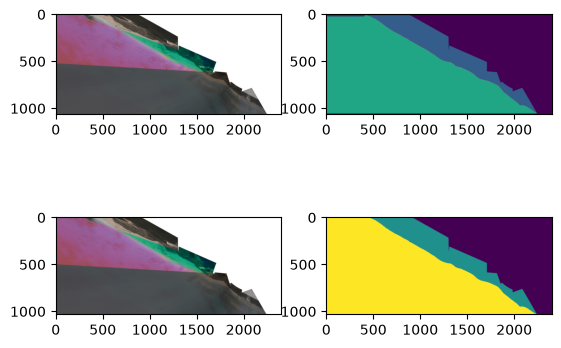

In [3]:
dataset_preprocessor = DatasetPreprocessor()

image = dataset_preprocessor.load_image(image_path)
mask = dataset_preprocessor.load_mask(mask_path)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

mapping = {
    0: 0,    # Background → Class 0
    25: 1,   # Not classified → Class 1
    75: 2,   # Land → Class 2
    150: 3,  # Sea → Class 3
    255: 4   # Shoreline → Class 4
}

# If we want only 3 classes:
mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 1,   # Land → Class 2
    150: 2,  # Sea → Class 3
    255: 1   # Shoreline → Class 4
}

new_image, new_mask = dataset_preprocessor.process_image(image, mask, mask_mapping=mapping, background_class=255, not_classified_class=25)

print("New image shape:", new_image.shape)
print("New mask shape:", new_mask.shape)

print("New mask unique values:", np.unique(new_mask))

fig, ax = plt.subplots(2, 2)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
ax[0][0].imshow(image)
ax[0][1].imshow(mask)

new_image = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)
ax[1][0].imshow(new_image)
ax[1][1].imshow(new_mask)

plt.show()

In [4]:
# Preprocess all the dataset
new_data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_snb/"))

dataset_preprocessor = DatasetPreprocessor()

mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 1,   # Land → Class 2
    150: 2,  # Sea → Class 3
    255: 1   # Shoreline → Class 4
}

dataset_preprocessor.preprocess(dataset_path=data_path, dataset_output_path=new_data_path, mask_mapping=mapping)

### New dataset

CoastData: global - 284 images
Coast: snb, Total size: 284
Image: /LOCALDATA/josep/code/Shoreline-extraction/data/processed_snb/images/snb_2017_11_26_11_00.image.jpg
Mask: /LOCALDATA/josep/code/Shoreline-extraction/data/processed_snb/masks/snb_2017_11_26_11_00.mask.png


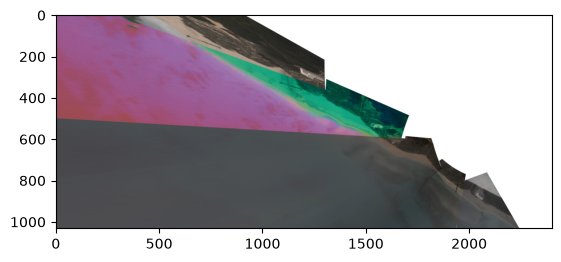

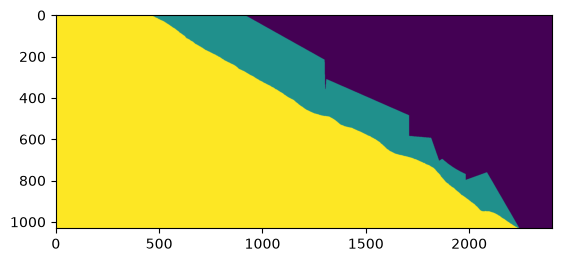

In [6]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/processed_snb/"))

# Load the data, all the different stations
data = CoastData(data_path)

filtered_data = data.get_images() 

filtered_data = data.split_data()

# Get the first image and mask
index = 1
image_path = filtered_data['train']['images'][index]
mask_path = filtered_data['train']['masks'][index]

print("Image:", image_path)
print("Mask:", mask_path)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img)
plt.show()

plt.imshow(mask)
plt.show()

# Keep only the shoreline

In [4]:
# Preprocess all the dataset
new_data_path = os.path.abspath(os.path.join(os.getcwd(), "../../data/processed_shoreline/"))

dataset_preprocessor = DatasetPreprocessor()

mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 0,   # Land → Class 2
    150: 0,  # Sea → Class 3
    255: 1   # Shoreline → Class 4
}

dataset_preprocessor.preprocess(dataset_path=data_path, dataset_output_path=new_data_path, mask_mapping=mapping)

# Keep 4 classes

In [5]:
# Preprocess all the dataset
new_data_path = os.path.abspath(os.path.join(os.getcwd(), "../../data/processed_4_classes/"))

dataset_preprocessor = DatasetPreprocessor()

mapping = {
    0: 0,    # Background → Class 0
    25: 0,   # Not classified → Class 1
    75: 1,   # Land → Class 2
    150: 2,  # Sea → Class 3
    255: 3   # Shoreline → Class 4
}

dataset_preprocessor.preprocess(dataset_path=data_path, dataset_output_path=new_data_path, mask_mapping=mapping)